**Aufgabe 4**

In dieser Aufgabe wird das "keras" API verwendet, um ein neuronales Netz (NN) wie in der Aufgabe 3 zu schreiben. Leider ist die Implementierung eines NN mit derselben Topologie kompliziert, aus diesem Grund schreiben wir einfaches NN mit der Struktur: 4 Inputsneuronen -> 1 Outputsneuron. Diese ist erreichbar mit dem Sequential-Model ohne Hidden-Layers.

**Aufgabe 4.a**

In der unteren Zelle verwenden wir die numpy-array-Repräsentation der Form (2,2) für die Inputbretter, die wir für die Aufgabe 3 implementiert haben. 1 steht für weißes Pixel und 0 für schwarzes. Für die Target-Menge gilt 1 ist Schachbrett und 0 kein Schachbrett

In [3]:
import aufgabe3.set_of_boards
from aufgabe3 import set_of_boards
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# ---------------------------------------------------------------------------
# 4a) Datenpraeparation
# ---------------------------------------------------------------------------
# Feature: alle 16 moeglichen 2x2-Muster, Shape (16, 2, 2)
X = set_of_boards.get_set_of_boards().astype("float32")
# Target: 1, wenn Schachbrettmuster (Diagonalen gleichfarbig), sonst 0
y = set_of_boards.get_targets().astype("float32")

# Da es nur 16 Kombinationen gibt, koennen wir laut Aufgabenstellung
# alle Muster sowohl fuer Training als auch fuer den Test verwenden.
x_train, y_train = X, y
x_test, y_test = X, y


**Aufgabe 2**

In der dieser Teilaufgabe wird das Lernmodel implementiert. Aktivierungsfunktion für das Input ist 'relu',  $$r(x) := \max(x, 0)$$ Diese stellt sicher, dass ein Neuron nur beim weißen Pixel aktiviert wird. Für das Otput verwenden wir Sigmoid-Funktion, $$\sigma: X \to [0,1]$$ was die Wahrscheinlichkeit gibt, dass das Input ein Schachbrett ist. Ist $\sigma(x) \geq 0.5$, dann ist es ein Schachbrett, ansonsten nicht.

In [4]:
model = Sequential([
    Flatten(input_shape=(2, 2)),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

**Aufgabe 4.c**

Nun die Kompilierung. Als am häufigsten verwendete Loss-Funktion, Optimizer und Metrics setzen wir binäre Kreuzentropie, Adam und Genauigkeit.

In [5]:
model.compile(
    loss="binary_crossentropy",
    optimizer="Adam",
    metrics=["accuracy"]
)

**Aufgabe 4.d**

Als der letzte Schritt führen wir Lernverfahren mit dem weiteren Test aus. Da die Input-Menge signifikant mehr nicht Schachbretter hat, muss die Loss-Funktion größeren Verlustwert geben, wenn das Model falsch ein Schachbrettmuster erkennt. Wir setzen Verlustwert für die Fehlklassifikation 'Schachbrett -> Nein' 5-fach größer als bei 'Kein Schachbrett -> Ja' ein. Weiterhin können Sie den verlauf des Lernverfahrens sehen, unter dem das Testergebnis steht.

Input | P(x = Schachbrett) | Aussage  

Brett | 0.0088 | Nein
Brett | 0.0059 | Nein
Brett | 0.0037 | Nein
Brett | 0.0000 | Nein
Brett | 0.0000 | Nein
Brett | 0.0052 | Nein
Schachbrett | 0.9961 | Ja
Brett | 0.0000 | Nein
Brett | 0.0000 | Nein
Schachbrett | 0.9958 | Ja
Brett | 0.0023 | Nein
Brett | 0.0000 | Nein
Brett | 0.0000 | Nein
Brett | 0.0055 | Nein
Brett | 0.0041 | Nein
Brett | 0.0093 | Nein

16/16 Muster korrekt klassifiziert.


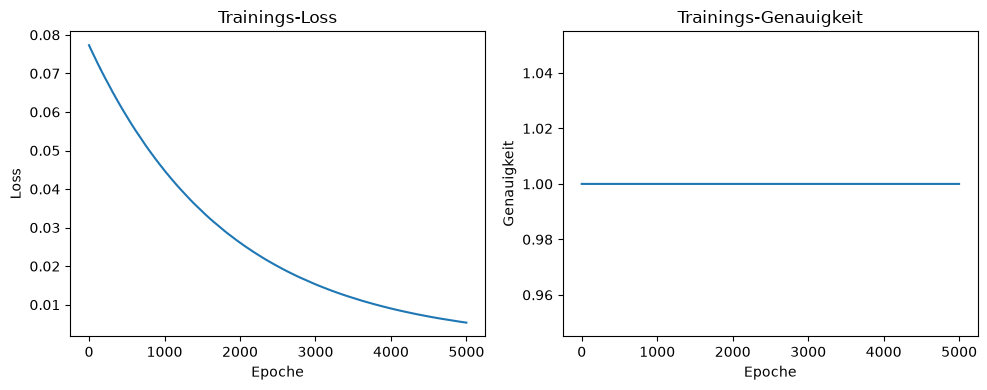

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5000,
    batch_size=16,
    verbose=0,
    class_weight={
        0: 1.0,
        1: 5.0
    }
)

loss, accuracy = model.evaluate(X, y, verbose=0)

predictions = model.predict(X, verbose=0).flatten()
print("Input | P(x = Schachbrett) | Aussage  \n")
for board, pred, target in zip(X, predictions, y):
    print(
        "Schachbrett" if int(target) == 1 else "Brett",
        "|",
        f"{pred:.4f}",
        "|",
        "Ja" if round(pred) == 1 else "Nein",
    )

korrekt = np.sum(np.round(predictions) == y_test)
print(f"\n{korrekt}/{len(y_test)} Muster korrekt klassifiziert.")
''

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history["loss"])
axes[0].set_xlabel("Epoche")
axes[0].set_ylabel("Loss")
axes[0].set_title("Trainings-Loss")

axes[1].plot(history.history["accuracy"])
axes[1].set_xlabel("Epoche")
axes[1].set_ylabel("Genauigkeit")
axes[1].set_title("Trainings-Genauigkeit")

plt.tight_layout()
plt.show()